# Capítulo 2 y Sección 5.3: Resultados del Aprendizaje No Supervisado
**Objetivos de la Evaluación:**
*   Implementación de múltiples algoritmos: **K-Means** y **Clustering Jerárquico**.
*   Justificación del número óptimo de clusters ($K$) mediante **Método del Codo** e **Índice Silhouette**.
*   Reducción de dimensionalidad y visualización estructural con **PCA (2D y 3D)** y **Dendrogramas**.
*   Análisis descriptivo del **perfil de pacientes** por cluster.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# 1. Carga de Datos
df = pd.read_csv("../data/processed/dataset_no_supervisado.csv")

# 2. Selección del espacio vectorial numérico
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cols_to_drop = ['id_registro', 'desc_fallecido', 'desc_ola']
features = [col for col in numeric_cols if col not in cols_to_drop]

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Muestreo estratificado (Optimización de RAM para métricas cuadráticas)
np.random.seed(42)
indices_m = np.random.choice(X_scaled.shape[0], size=5000, replace=False)
X_muestra = X_scaled[indices_m]

print(f"Pipeline inicializado. Dataset procesado: {X_scaled.shape[1]} variables y {X_scaled.shape[0]} registros.")

Pipeline inicializado. Dataset procesado: 16 variables y 49515 registros.


## 1. Determinación del Número Óptimo de Clusters
Evaluamos el espacio métrico calculando simultáneamente la Inercia (varianza intra-cluster) y el Coeficiente de Silhouette (separación inter-cluster).

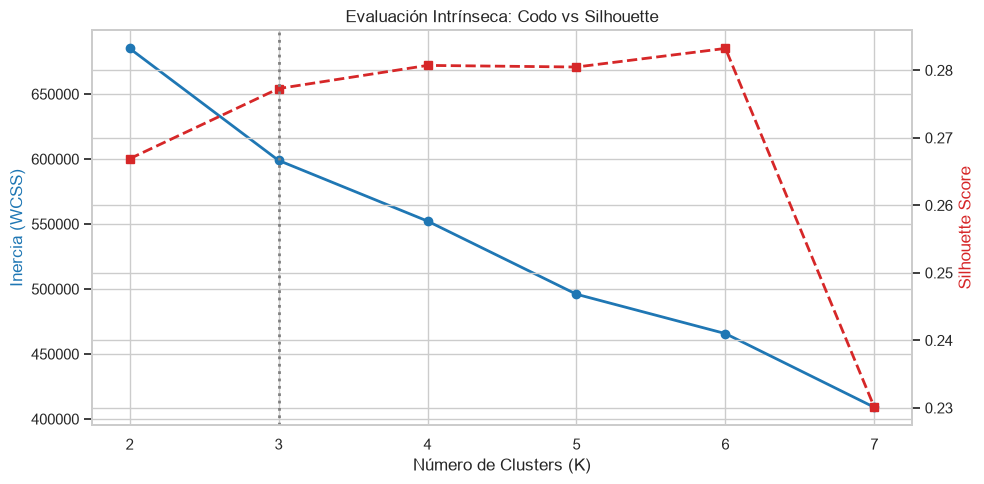

In [17]:
inercia = []
silhouette_avg = []
rango_k = range(2, 8)

for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inercia.append(kmeans_temp.inertia_)
    silhouette_avg.append(silhouette_score(X_muestra, kmeans_temp.predict(X_muestra)))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(rango_k, inercia, marker='o', color='tab:blue', linewidth=2, label='Inercia (Codo)')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia (WCSS)', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(rango_k, silhouette_avg, marker='s', linestyle='--', color='tab:red', linewidth=2, label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='tab:red')

plt.title('Evaluación Intrínseca: Codo vs Silhouette')
plt.axvline(x=3, color='gray', linestyle=':', linewidth=2, label='K Óptimo = 3')
fig.tight_layout()
plt.show()

## 2. Implementación de Algoritmos (K-Means vs Jerárquico)
Atendiendo a la selección sugerida, ejecutamos un enfoque particional (K-Means) y un enfoque aglomerativo (Jerárquico) configurados con el $K=3$ descubierto.

In [18]:
k_optimo = 3

# Algoritmo 1: K-Means (Modelo final asignado a toda la data)
modelo_kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['Cluster_KMeans'] = modelo_kmeans.fit_predict(X_scaled)

# Algoritmo 2: Clustering Jerárquico (Sobre muestra para evitar colapso de RAM)
modelo_jerarquico = AgglomerativeClustering(n_clusters=k_optimo)
labels_jerarquico = modelo_jerarquico.fit_predict(X_muestra)

sil_km = silhouette_score(X_muestra, df.loc[indices_m, 'Cluster_KMeans'])
sil_jer = silhouette_score(X_muestra, labels_jerarquico)

print(f"Rendimiento del espacio latente (Silhouette Score):")
print(f"- K-Means: {sil_km:.4f}")
print(f"- Clustering Jerárquico: {sil_jer:.4f}")

Rendimiento del espacio latente (Silhouette Score):
- K-Means: 0.2773
- Clustering Jerárquico: 0.2140


## 3. Resultados Visuales: Topología y Dimensionalidad (Dendrograma y PCA)
Reducimos la dimensionalidad para graficar la estructura natural de los datos y confirmamos el número de macro-grupos mediante enlaces de Ward.

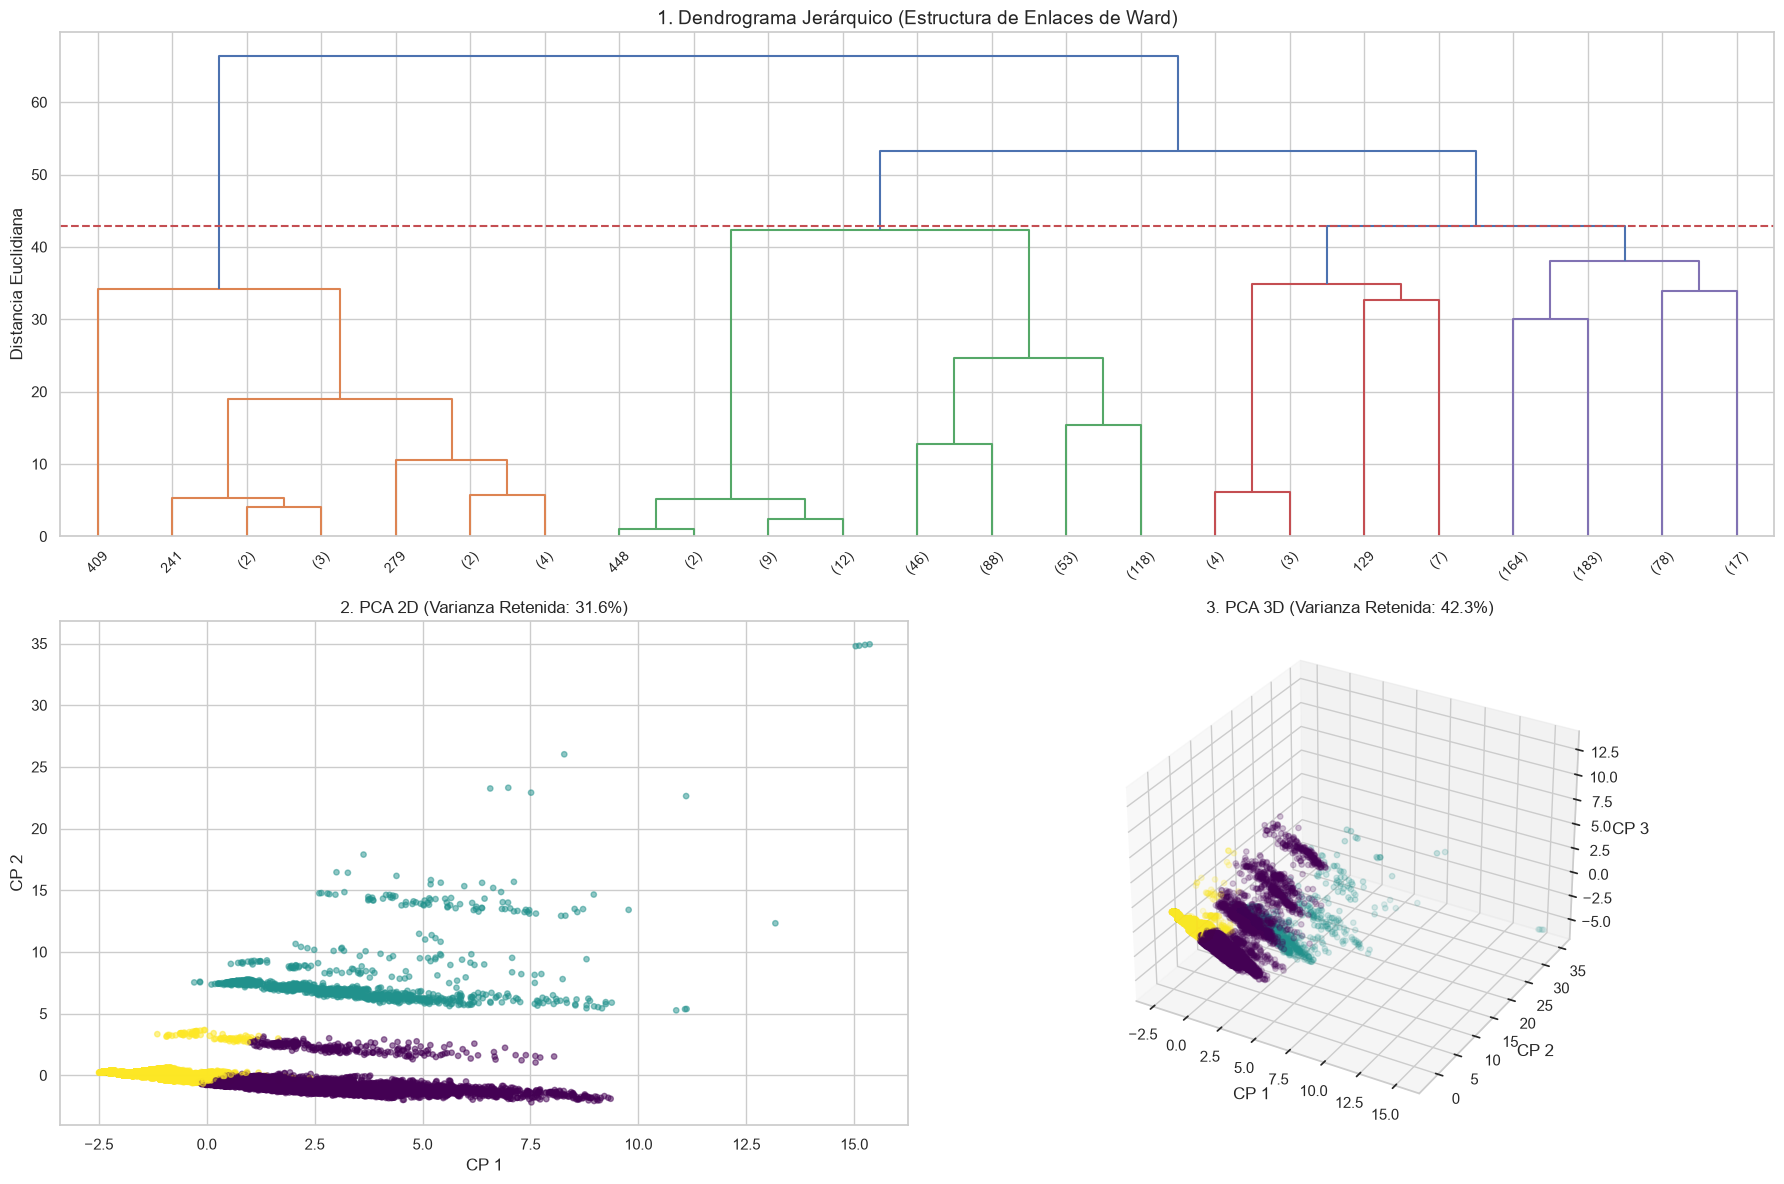

In [19]:
fig = plt.figure(figsize=(18, 12))

# 1. DENDROGRAMA (Sub-muestra de 800 para legibilidad)
X_dendro = X_scaled[np.random.choice(X_scaled.shape[0], 800, replace=False)]
Z = linkage(X_dendro, method='ward')
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
dendrogram(Z, truncate_mode='level', p=4, color_threshold=Z[-3, 2], ax=ax1)
ax1.set_title("1. Dendrograma Jerárquico (Estructura de Enlaces de Ward)", fontsize=14)
ax1.set_ylabel("Distancia Euclidiana")
ax1.axhline(y=Z[-3, 2], color='r', linestyle='--')

# 2. PCA 2D y 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

ax2 = plt.subplot2grid((2, 2), (1, 0))
scatter2d = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_KMeans'], cmap='viridis', alpha=0.5, s=15)
ax2.set_title(f'2. PCA 2D (Varianza Retenida: {sum(pca.explained_variance_ratio_[:2]):.1%})')
ax2.set_xlabel('CP 1')
ax2.set_ylabel('CP 2')

ax3 = plt.subplot2grid((2, 2), (1, 1), projection='3d')
scatter3d = ax3.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df['Cluster_KMeans'], cmap='viridis', alpha=0.5, s=15)
ax3.set_title(f'3. PCA 3D (Varianza Retenida: {sum(pca.explained_variance_ratio_):.1%})')
ax3.set_xlabel('CP 1')
ax3.set_ylabel('CP 2')
ax3.set_zlabel('CP 3')

plt.tight_layout()
plt.show()

## 4. Descripción de Resultados: Perfilamiento de Clusters
Análisis de las características descriptivas centrales que definen fenotípicamente a cada agrupación.

In [21]:
features_clave = ['edad', 'n_sintomas', 'fiebre', 'tos', 'malestar', 'cardiovascular', 'diabetes']
perfil_clusters = df.groupby('Cluster_KMeans')[features_clave].mean()

nombres_clusters = {
    0: 'Grupo 1: Sintomáticos Agudos',
    2: 'Grupo 2: Asintomáticos / Leves',
    1: 'Grupo 3: Riesgo Crónico'
}
perfil_clusters.index = perfil_clusters.index.map(nombres_clusters)

print("=== PERFIL PROMEDIO DE LOS CLUSTERS DESCUBIERTOS ===")
display(perfil_clusters.round(3).style.background_gradient(cmap='YlOrRd'))

print("DISTRIBUCIÓN POBLACIONAL")
conteo = df['Cluster_KMeans'].map(nombres_clusters).value_counts()
for nombre, cantidad in conteo.items():
    print(f"- {nombre}: {cantidad} pacientes ({cantidad/len(df):.1%})")

=== PERFIL PROMEDIO DE LOS CLUSTERS DESCUBIERTOS ===


,edad,n_sintomas,fiebre,tos,malestar,cardiovascular,diabetes
Cluster_KMeans,,,,,,,
Grupo 1: Sintomáticos Agudos,0.453000,0.325000,0.652000,0.803000,0.713000,0.000000,0.000000
Grupo 3: Riesgo Crónico,0.573000,0.221000,0.367000,0.510000,0.438000,0.476000,0.459000
Grupo 2: Asintomáticos / Leves,0.387000,0.064000,0.062000,0.154000,0.086000,0.000000,0.000000


DISTRIBUCIÓN POBLACIONAL
- Grupo 2: Asintomáticos / Leves: 30517 pacientes (61.6%)
- Grupo 1: Sintomáticos Agudos: 17741 pacientes (35.8%)
- Grupo 3: Riesgo Crónico: 1257 pacientes (2.5%)
